In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:

gpt_def = pd.read_csv('/home/data/v.moskvoretskii/TaxoGen/data/main_gpt4_def_with_flux.csv_elo.csv')
gpt_nodef = pd.read_csv('/home/data/v.moskvoretskii/TaxoGen/data/main_gpt4_nodef_with_flux.csv_elo.csv')


human_def = pd.read_csv('/home/data/v.moskvoretskii/TaxoGen/data/labeling/human_with_flux_def_final.csv_elo.csv')
human_nodef = pd.read_csv('/home/data/v.moskvoretskii/TaxoGen/data/labeling/human_with_flux_nodef_final.csv_elo.csv')

In [3]:
name_of_columns = {
    'stabilityai_sdxl-turbo': 'SDXL-turbo',
    'retrieval': 'Retrieval',
    'runwayml_stable-diffusion-v1-5': 'SD1.5',
    'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 'HDiT',
    'playgroundai_playground-v2.5-1024px-aesthetic': 'Playground',
    'prompthero_openjourney': 'Openjourney',
    'kandinsky-community_kandinsky-3': 'Kandinsky3',
    'stabilityai_stable-diffusion-xl-base-1.0': 'SDXL',
    'PixArt-alpha_PixArt-Sigma-XL-2-512-MS': 'PixArt',
    'DeepFloyd_IF-I-XL-v1.0': 'DeepFloyd',
    'stabilityai_stable-diffusion-3-medium-diffusers': 'SD3',
    'black-forest-labs_FLUX.1-dev': 'FLUX'
}

In [4]:
gpt_def['model'] = gpt_def['model'].replace(name_of_columns)
gpt_models = gpt_def['model'].values
gpt_scores = gpt_def['score'].values

gpt_ci_lower = (gpt_def['lower'] - gpt_def['score']).values
gpt_ci_upper = (gpt_def['upper'] - gpt_def['score']).values

gpt_ci_adjusted = np.array([gpt_ci_upper, np.abs(gpt_ci_lower)])


# HUMAN

human_def['model'] = human_def['model'].replace(name_of_columns)
human_models = human_def['model'].values
human_scores = human_def['score'].values

human_ci_lower = (human_def['lower'] - human_def['score']).values
human_ci_upper = (human_def['upper'] - human_def['score']).values

human_ci_adjusted = np.array([human_ci_upper, np.abs(human_ci_lower)])



/tmp/ipykernel_1383050/956475298.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(human_models, human_scores, yerr=[np.abs(human_ci_lower), human_ci_upper], fmt='o',
/tmp/ipykernel_1383050/956475298.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
/tmp/ipykernel_1383050/956475298.py:15: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(gpt_models, gpt_scores, yerr=gpt_ci_adjusted, fmt='o', ecolor='#999999',
/tmp/ipykernel_1383050/956475298.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

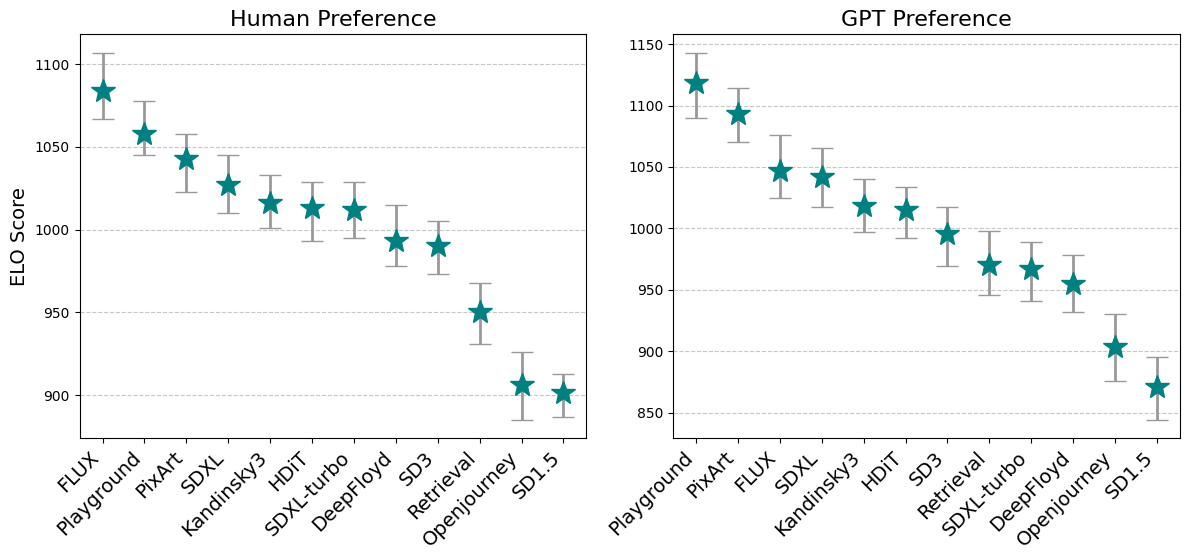

In [5]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Human-rated models
ax1.errorbar(human_models, human_scores, yerr=[np.abs(human_ci_lower), human_ci_upper], fmt='o', 
             ecolor='#999999', capsize=8, linestyle='', color='teal', marker='*', 
             markersize=18, elinewidth=2)
ax1.set_title('Human Preference', fontsize=16)
ax1.set_xlabel('')
ax1.set_ylabel('ELO Score', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot GPT-rated models
ax2.errorbar(gpt_models, gpt_scores, yerr=gpt_ci_adjusted, fmt='o', ecolor='#999999', 
             capsize=8, linestyle='', color='teal', marker='*', markersize=18, elinewidth=2)
ax2.set_title('GPT Preference', fontsize=16)
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
#plt.subplots_adjust(wspace=0.4)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust to fit titles
plt.savefig('ELO_human_gpt_def_with_flux2.pdf', dpi=3000, bbox_inches='tight')
plt.show()


/tmp/ipykernel_19781/1502106652.py:26: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax1.errorbar(human_models, human_scores, yerr=[np.abs(human_ci_lower), human_ci_upper], fmt='o',
/tmp/ipykernel_19781/1502106652.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
/tmp/ipykernel_19781/1502106652.py:36: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.errorbar(gpt_models, gpt_scores, yerr=gpt_ci_adjusted, fmt='o', ecolor='#999999',
/tmp/ipykernel_19781/1502106652.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


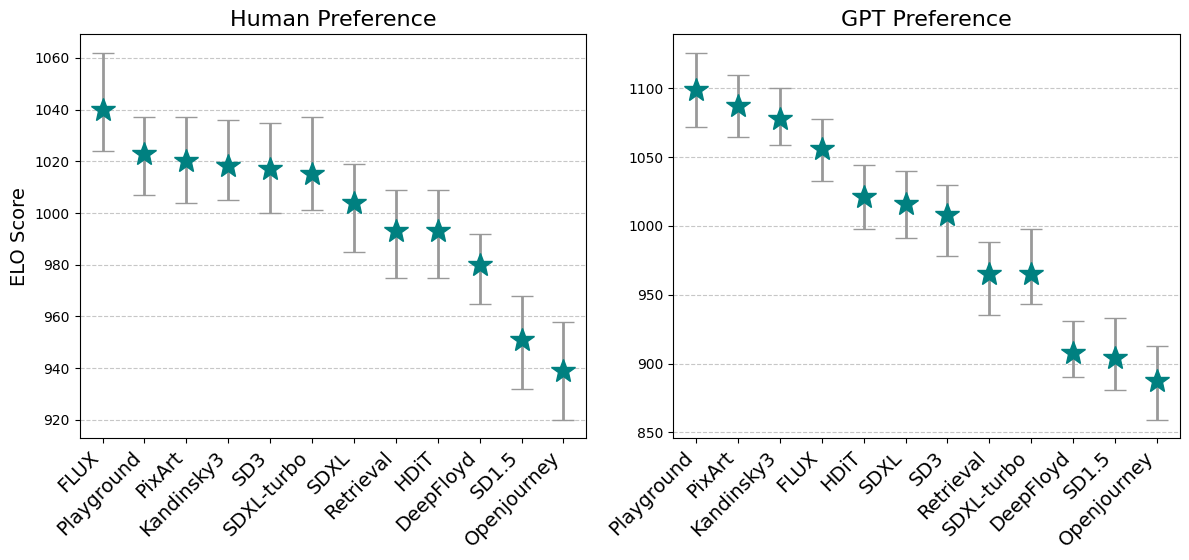

In [43]:
gpt_nodef['model'] = gpt_nodef['model'].replace(name_of_columns)
gpt_models = gpt_nodef['model'].values
gpt_scores = gpt_nodef['score'].values

gpt_ci_lower = (gpt_nodef['lower'] - gpt_nodef['score']).values
gpt_ci_upper = (gpt_nodef['upper'] - gpt_nodef['score']).values

gpt_ci_adjusted = np.array([gpt_ci_upper, np.abs(gpt_ci_lower)])


# HUMAN

human_nodef['model'] = human_nodef['model'].replace(name_of_columns)
human_models = human_nodef['model'].values
human_scores = human_nodef['score'].values

human_ci_lower = (human_nodef['lower'] - human_nodef['score']).values
human_ci_upper = (human_nodef['upper'] - human_nodef['score']).values

human_ci_adjusted = np.array([human_ci_upper, np.abs(human_ci_lower)])

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Human-rated models
ax1.errorbar(human_models, human_scores, yerr=[np.abs(human_ci_lower), human_ci_upper], fmt='o', 
             ecolor='#999999', capsize=8, linestyle='', color='teal', marker='*', 
             markersize=18, elinewidth=2)
ax1.set_title('Human Preference', fontsize=16)
ax1.set_xlabel('')
ax1.set_ylabel('ELO Score', fontsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Plot GPT-rated models
ax2.errorbar(gpt_models, gpt_scores, yerr=gpt_ci_adjusted, fmt='o', ecolor='#999999', 
             capsize=8, linestyle='', color='teal', marker='*', markersize=18, elinewidth=2)
ax2.set_title('GPT Preference', fontsize=16)
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
#plt.subplots_adjust(wspace=0.4)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust to fit titles
plt.savefig('ELO_human_gpt_nodef_with_flux.pdf', dpi=3000, bbox_inches='tight')
plt.show()


In [44]:
human_def = human_def.merge(gpt_def[['model', 'score']], on='model', suffixes=('', '_gpt'))


# Pearson correlation (just for reference, not recommended for discrete data)
pearson_corr = human_def['score'].corr(human_def['score_gpt'], method='pearson')

# Spearman rank correlation (recommended)
spearman_corr = human_def['score'].corr(human_def['score_gpt'], method='spearman')

# Kendall Tau correlation (also suitable for ordinal data)
kendall_corr = human_def['score'].corr(human_def['score_gpt'], method='kendall')

# Display results
print(f"Pearson correlation: {pearson_corr}")
print(f"Spearman correlation: {spearman_corr}")
print(f"Kendall Tau correlation: {kendall_corr}")

Pearson correlation: 0.9153930841854535
Spearman correlation: 0.9230769230769231
Kendall Tau correlation: 0.8181818181818181


In [45]:
# Pearson correlation (just for reference, not recommended for discrete data)
#pearson_corr = human_def['score'].corr(human_def['score_gpt'], method='pearson')

# Spearman rank correlation (recommended)
spearman_corr = human_def['model'].corr(gpt_def['model'], method='spearman')

# Kendall Tau correlation (also suitable for ordinal data)
kendall_corr = human_def['model'].corr(gpt_def['model'], method='kendall')

# Display results
print(f"Pearson correlation: {pearson_corr}")
print(f"Spearman correlation: {spearman_corr}")
print(f"Kendall Tau correlation: {kendall_corr}")

Pearson correlation: 0.9153930841854535
Spearman correlation: 0.4825174825174825
Kendall Tau correlation: 0.2727272727272727
